In [1]:
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
import sympy as sm
import sympy.physics.mechanics as me

me.init_vprinting(use_latex='mathjax')

q1, q2, q3 = me.dynamicsymbols('q_1 q_2 q_3')
u1, u2, u3 = me.dynamicsymbols('u_1, u_2, u_3')
d0, d1, d2, d3 = sm.symbols('d_0 d_1 d_2 d_3')
r1, r2 = sm.symbols('r_1 r_2')
m1, m2, I1, I2 = sm.symbols('m_1 m_2 I_1 I_2')
k1, k2 = sm.symbols('k_1 k_2')
theta1F, theta2F = sm.symbols('\\theta_{1F} \\theta_{2F}')

t = me.dynamicsymbols._t

p = sm.Matrix([d0, d1, d2, d3, r1, r2, m1, m2, I1, I2, theta1F, theta2F, k1, k2])

q = sm.Matrix([q1])
qr = sm.Matrix([q2, q3])
qN = q.col_join(qr)

u = sm.Matrix([u1])
ur = sm.Matrix([u2, u3])
uN = u.col_join(ur)

qdN = qN.diff(t)
ud = u.diff(t)

p, q, qr, qN, u, ur, uN, qdN, ud

⎛⎡    d₀     ⎤                                                ⎞
⎜⎢           ⎥                                                ⎟
⎜⎢    d₁     ⎥                                                ⎟
⎜⎢           ⎥                                                ⎟
⎜⎢    d₂     ⎥                                                ⎟
⎜⎢           ⎥                                                ⎟
⎜⎢    d₃     ⎥                                                ⎟
⎜⎢           ⎥                                                ⎟
⎜⎢    r₁     ⎥                                                ⎟
⎜⎢           ⎥                                                ⎟
⎜⎢    r₂     ⎥                                                ⎟
⎜⎢           ⎥              ⎡q₁⎤              ⎡u₁⎤  ⎡q₁̇⎤      ⎟
⎜⎢    m₁     ⎥        ⎡q₂⎤  ⎢  ⎥        ⎡u₂⎤  ⎢  ⎥  ⎢  ⎥      ⎟
⎜⎢           ⎥, [q₁], ⎢  ⎥, ⎢q₂⎥, [u₁], ⎢  ⎥, ⎢u₂⎥, ⎢q₂̇⎥, [u₁̇]⎟
⎜⎢    m₂     ⎥        ⎣q₃⎦  ⎢  ⎥        ⎣u₃⎦  ⎢  ⎥  ⎢  ⎥      ⎟
⎜⎢           ⎥              ⎣q₃⎦     

In [2]:
ur_zero = {ui: 0 for ui in ur}
uN_zero = {ui: 0 for ui in uN}
qdN_zero = {qdi: 0 for qdi in qdN}
ud_zero = {udi: 0 for udi in ud}

In [3]:
RN = me.ReferenceFrame('R_N')
R1 = me.ReferenceFrame('R_1')
R2 = me.ReferenceFrame('R_2')
R3 = me.ReferenceFrame('R_3')

R1.orient_axis(RN, q1, RN.z)
R2.orient_axis(R1, q2, R1.z)
R3.orient_axis(R2, q3, R2.z)

A = me.Point('A')
B = me.Point('B')
C = me.Point('C')
D = me.Point('D')

In [50]:
C.set_pos(D, d1*R1.x)
B.set_pos(C, d2*R2.x)
A.set_pos(B, d3*R3.x)

A.pos_from(D)

d₃ r_3_x + d₂ r_2_x + d₁ r_1_x

In [66]:
r_D_A = -d0*RN.x
loop = A.pos_from(D) - r_D_A
loop

d₃ r_3_x + d₂ r_2_x + d₁ r_1_x + d₀ r_n_x

In [67]:
fhx = sm.trigsimp(loop.dot(RN.x))
fhx

d₀ + d₁⋅cos(q₁) + d₂⋅cos(q₁ + q₂) + d₃⋅cos(q₁ + q₂ + q₃)

In [68]:
fhy = sm.trigsimp(loop.dot(RN.y))
fhy

d₁⋅sin(q₁) + d₂⋅sin(q₁ + q₂) + d₃⋅sin(q₁ + q₂ + q₃)

In [69]:
fh = sm.Matrix([fhx, fhy])
fh

⎡d₀ + d₁⋅cos(q₁) + d₂⋅cos(q₁ + q₂) + d₃⋅cos(q₁ + q₂ + q₃)⎤
⎢                                                        ⎥
⎣  d₁⋅sin(q₁) + d₂⋅sin(q₁ + q₂) + d₃⋅sin(q₁ + q₂ + q₃)   ⎦

In [70]:
me.find_dynamicsymbols(fh)

{q₁, q₂, q₃}

In [71]:
fk = sm.Matrix([
    q1.diff(t) - u1,
    q2.diff(t) - u2,
    q3.diff(t) - u3,
])
Mk = fk.jacobian(qdN)
gk = fk.xreplace(qdN_zero)
qdN_sol = -Mk.LUsolve(gk)
qd_repl = dict(zip(qdN, qdN_sol))
qd_repl

{q₁̇: u₁, q₂̇: u₂, q₃̇: u₃}

In [72]:
t = me.dynamicsymbols._t
fhd = fh.diff(t).xreplace(qd_repl)
fhd

⎡-d₁⋅u₁⋅sin(q₁) - d₂⋅(u₁ + u₂)⋅sin(q₁ + q₂) - d₃⋅(u₁ + u₂ + u₃)⋅sin(q₁ + q₂ + 
⎢                                                                             
⎣d₁⋅u₁⋅cos(q₁) + d₂⋅(u₁ + u₂)⋅cos(q₁ + q₂) + d₃⋅(u₁ + u₂ + u₃)⋅cos(q₁ + q₂ + q

q₃)⎤
   ⎥
₃) ⎦

In [73]:
me.find_dynamicsymbols(fhd)

{q₁, q₂, q₃, u₁, u₂, u₃}

In [74]:
Mhd = fhd.jacobian(ur)
ghd = fhd.xreplace(ur_zero)
ur_sol = sm.trigsimp(-Mhd.LUsolve(ghd))
ur_repl = dict(zip(ur, ur_sol))

In [75]:
ur_repl[u2]

                 d₁⋅(d₂⋅sin(q₂) + d₃⋅sin(q₂ + q₃))⋅u₁⋅sin(q₁ + q₂ + q₃)       
-d₁⋅u₁⋅sin(q₁) - ────────────────────────────────────────────────────── - d₂⋅u
                                       d₂⋅sin(q₃)                             
──────────────────────────────────────────────────────────────────────────────
                                        d₂⋅sin(q₁ + q₂) + d₃⋅sin(q₁ + q₂ + q₃)

                                        
₁⋅sin(q₁ + q₂) - d₃⋅u₁⋅sin(q₁ + q₂ + q₃)
                                        
────────────────────────────────────────
                                        

In [76]:
ur_repl[u3]

d₁⋅(d₂⋅sin(q₂) + d₃⋅sin(q₂ + q₃))⋅u₁
────────────────────────────────────
           d₂⋅d₃⋅sin(q₃)            

In [77]:
R1.set_ang_vel(RN, u1*RN.z)
R2.set_ang_vel(R1, ur_repl[u2]*R1.z)
R3.set_ang_vel(R2, ur_repl[u3]*R2.z)

In [78]:
D.set_vel(RN, 0)
C.v2pt_theory(D, RN, R1)
B.v2pt_theory(C, RN, R2)
A.v2pt_theory(B, RN, R3)

(me.find_dynamicsymbols(C.vel(RN), reference_frame=RN) |
 me.find_dynamicsymbols(B.vel(RN), reference_frame=RN) |
 me.find_dynamicsymbols(A.vel(RN), reference_frame=RN))

{q₁, q₂, q₃, u₁}

In [79]:
gk = gk.xreplace(ur_repl)

In [80]:
# Generalized active force
TR1 =  k1*(theta1F - q1)*R1.z + k2*(q2 - theta2F)*R1.z
TR2 = -k2*(q2 - theta2F)*R2.z

In [81]:
Fr = sm.Matrix([
    R1.ang_vel_in(RN).diff(u1, RN).dot(TR1) + R2.ang_vel_in(RN).diff(u1, RN).dot(TR2)
])
Fr

⎡                                               ⎛              d₁⋅(d₂⋅sin(q₂) 
⎢                        k₂⋅(-\theta_{2F} + q₂)⋅⎜-d₁⋅sin(q₁) - ───────────────
⎢                                               ⎝                             
⎢k₁⋅(\theta_{1F} - q₁) - ─────────────────────────────────────────────────────
⎣                                                                       d₂⋅sin

+ d₃⋅sin(q₂ + q₃))⋅sin(q₁ + q₂ + q₃)                                         ⎞
──────────────────────────────────── - d₂⋅sin(q₁ + q₂) - d₃⋅sin(q₁ + q₂ + q₃)⎟
      d₂⋅sin(q₃)                                                             ⎠
──────────────────────────────────────────────────────────────────────────────
(q₁ + q₂) + d₃⋅sin(q₁ + q₂ + q₃)                                              

⎤
⎥
⎥
⎥
⎦

In [82]:
me.find_dynamicsymbols(Fr)

{q₁, q₂, q₃}

In [83]:
# Generalized inertia forces
P1star = me.Point('P_1*')
P2star = me.Point('P_2*')

P1star.set_pos(D, r1*R1.x)
P2star.set_pos(C, r2*R2.x)

P1star.v2pt_theory(D, RN, R1)
P2star.v2pt_theory(C, RN, R2)

                 ⎛                      d₁⋅(d₂⋅sin(q₂) + d₃⋅sin(q₂ + q₃))⋅u₁⋅s
                 ⎜     -d₁⋅u₁⋅sin(q₁) - ──────────────────────────────────────
                 ⎜                                            d₂⋅sin(q₃)
d₁⋅u₁ r_1_y + r₂⋅⎜u₁ + ───────────────────────────────────────────────────────
                 ⎝                                             d₂⋅sin(q₁ + q₂)

in(q₁ + q₂ + q₃)                                               ⎞
──────────────── - d₂⋅u₁⋅sin(q₁ + q₂) - d₃⋅u₁⋅sin(q₁ + q₂ + q₃)⎟
                                                               ⎟
───────────────────────────────────────────────────────────────⎟ r_2_y
 + d₃⋅sin(q₁ + q₂ + q₃)                                        ⎠

In [84]:
me.find_dynamicsymbols(P1star.acc(RN), reference_frame=RN)

{q₁, u₁, u₁̇}

In [85]:
me.find_dynamicsymbols(P2star.acc(RN), reference_frame=RN)

{q₁, q₂, q₃, u₁, q₁̇, q₂̇, q₃̇, u₁̇}

In [86]:
Rs_P1star = -m1*P1star.acc(RN)
Rs_P2star = -m2*P2star.acc(RN).xreplace(qd_repl).xreplace(ur_repl)

# Rod inertias
inertia1 = I1*me.outer(R1.z, R1.z)
inertia2 = I2*me.outer(R2.z, R2.z)

Ts1 = -(R1.ang_acc_in(RN).dot(inertia1) + me.cross(R1.ang_vel_in(RN), inertia1).dot(R1.ang_vel_in(RN)))
Ts2 = -(R2.ang_acc_in(RN).dot(inertia2) + me.cross(R2.ang_vel_in(RN), inertia2).dot(R2.ang_vel_in(RN))).xreplace(qd_repl).xreplace(ur_repl)

Frs = sm.Matrix([
    P1star.vel(RN).diff(u1, RN).dot(Rs_P1star) + P2star.vel(RN).diff(u1, RN).dot(Rs_P2star) + R1.ang_vel_in(RN).diff(u1, RN).dot(Ts1) + R2.ang_vel_in(RN).diff(u1, RN).dot(Ts2) 
])
me.find_dynamicsymbols(Frs)

{q₁, q₂, q₃, u₁, u₁̇}

In [87]:
# Equations of motion
Md = Frs.jacobian(ud)
gd = Frs.xreplace(ud_zero) + Fr

In [88]:
me.find_dynamicsymbols(Mk), me.find_dynamicsymbols(gk)

(set(), {q₁, q₂, q₃, u₁})

In [89]:
me.find_dynamicsymbols(Md), me.find_dynamicsymbols(gd)

({q₁, q₂, q₃}, {q₁, q₂, q₃, u₁})

In [90]:
Mk.free_symbols | gk.free_symbols | Md.free_symbols | gd.free_symbols

{I₁, I₂, \theta_{1F}, \theta_{2F}, d₁, d₂, d₃, k₁, k₂, m₁, m₂, r₁, r₂, t}

In [91]:
eval_k = sm.lambdify((qN, u, p), (Mk, gk))
eval_d = sm.lambdify((qN, u, p), (Md, gd))

In [92]:
# q values just for try
q_vals = np.array([
    np.deg2rad(10.0),  # q1, rad
    np.deg2rad(10.0),  # q2, rad
    np.deg2rad(10.0),  # q3, rad
])
q_vals, type(q_vals), q_vals.shape

(array([0.17453293, 0.17453293, 0.17453293]), numpy.ndarray, (3,))

In [93]:
# u values just for try
u_vals = np.array([
    0.1,  # u1, rad/s
])
u_vals, type(u_vals), u_vals.shape

(array([0.1]), numpy.ndarray, (1,))

In [179]:
# Parameter values

p_vals = np.array([
    0.15225, # d0, m
    1.32588, # d1, m
    0.08024, # d2, m
    1.4165, # d3, m
    0.8915, # r1, m
    1.8288, # r2, m
    8.899, # m1, kg
    36.891, # m2, kg
    0.9369, # I1, kgm^2
    43.527, # I2, kgm^2
    np.deg2rad(240.0), # theta1F, rad
    np.deg2rad(298.0), # theta2Fo, rad
    0.6114, # k1, Nm/rad
    -0.776, # k2o, Nm/rad
]) 
p_vals, type(p_vals), p_vals.shape

(array([ 0.15225   ,  1.32588   ,  0.08024   ,  1.4165    ,  0.8915    ,
         1.8288    ,  8.899     , 36.891     ,  0.9369    , 43.527     ,
         4.1887902 ,  5.20108117,  0.6114    , -0.776     ]),
 numpy.ndarray,
 (14,))

In [180]:
# Matrix values just for try
Mk_vals, gk_vals, = eval_k(q_vals, u_vals, p_vals)
Md_vals, gd_vals = eval_d(q_vals, u_vals, p_vals)
Mk_vals, gk_vals, Md_vals, gd_vals

(array([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]]),
 array([[-0.1       ],
        [ 3.35457852],
        [-3.34818106]]),
 array([[-171133.76295802]]),
 array([[330871.33742392]]))

In [181]:
def eval_rhs(t, x, p):
    """Return the derivative of the state at time t.
    Parameters
    ==========
    t : float
    x : array_like, shape(4,)
        x = [q1, q2, q3, u1]
    p : array_like, shape(6,)
        p = [la, lb, lc, ln, m, g]
    Returns
    =======
    xd : ndarray, shape(4,)
        xd = [q1d, q2d, q3d, u1d]
    """
    
    qN = x[:3] # shape(3,)
    u = x[3:] # shape(1,)
    
    Mk, gk = eval_k(qN, u, p)
    qNd = -np.linalg.solve(Mk, np.squeeze(gk))
    
    # Md, gd, and ud are each shape(1,1)
    Md, gd = eval_d(qN, u, p)
    ud = -np.linalg.solve(Md, gd)[0]
    
    return np.hstack((qNd, ud))

In [182]:
# If we needed to find the initial values from one joint value (q1). This is not our case

#from scipy.optimize import fsolve

#eval_fh = sm.lambdify((qr, q1, p), fh)

#q2_val, q3_val = fsolve(
#lambda qr, q1, p: np.squeeze(eval_fh(qr, q1, p)), # squeeze to a 1d array
#qr_guess, # initial guess for q2 and q3
#args=(q1_val, p_vals)) # known values in fh

In [183]:
from scipy.integrate import solve_ivp

# Initial generalized coordinates and generalized speeds
qN0 = [np.deg2rad(0.294),np.deg2rad(172.817), np.deg2rad(7.283)] 
uN0 = [0]

# Initial time
t0 = 0.0 # s

# Final time
tf = 10.5 # s

# Time span
t_span = [t0, tf] 

# Initial conditions.
y0 = np.array(qN0 + uN0)  

# q2 update event
def event_q2(t,y,p):
    return y[1] - np.deg2rad(5.0) # q2 joint update
event_q2.terminal = True # Ends the integration
event_q2.direction = -1 # Detect values from positive to negative
active_event = 1 # Variable to specify that the event is active or not

# Simulation
total_time = []
total_states = []

initial_t = t_span[0]

while initial_t < t_span[1]:
    
    event = []
    if active_event:
        event.append(event_q2)
        
    # Integrate the system with active events
    sol = solve_ivp(eval_rhs, [initial_t, t_span[1]], y0, args=(p_vals,), events=event, dense_output=True)
    
    # Save partial results
    total_time.append(sol.t)
    total_states.append(sol.y)
 
    print(sol.t_events)
    print(sol.y_events)
    # Check if any event occurred
    if len(event) > 0 and sol.t_events[0].size > 0:  # If the event occurred
        t_event = sol.t_events[0][0]
        y_event = sol.y_events[0][0]

        # Update stiffness and the final angle 
        p_vals[11] = np.deg2rad(12.7) # thetaF2
        p_vals[13] = -40.1 # k2
        
        # Deactivate the event
        active_event = 0

        # Update the intial conditions
        y0 = sol.sol(t_event) + 1e-6
        initial_t = t_event  # Avoid re-integrating at the same point  
    else:
        # If there were no events, finish the simulation
        break

# Combine results into single arrays
ts = np.concatenate(total_time)
ys = np.hstack(total_states)

[array([10.209553])]
[array([[1.52438402, 0.08726646, 2.93871845, 0.04157713]])]
[]
[]


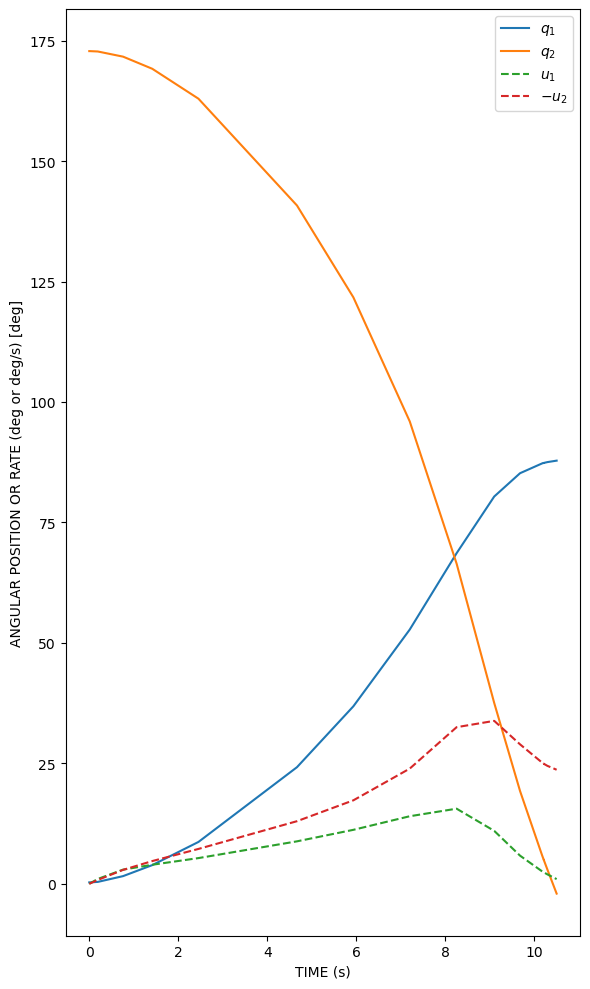

In [196]:
import matplotlib.pyplot as plt

u2_func = sm.lambdify((q1, q2, q3, u1, p), ur_sol[0])

u2_vals = u2_func(ys[0,:], ys[1,:], ys[2,:], ys[3,:], p_vals)

fig, axes = plt.subplots(1,1, sharex=True)
fig.set_size_inches((6.0, 10.0))

axes.plot(ts, np.rad2deg(ys[0,:]))
axes.plot(ts, np.rad2deg(ys[1,:]))
axes.plot(ts, np.rad2deg(ys[3,:]), '--')
axes.plot(ts, np.rad2deg(-u2_vals), '--')
axes.legend([me.vlatex(qN[0], mode='inline'), me.vlatex(qN[1], mode='inline'), me.vlatex(uN[0], mode='inline'), me.vlatex(-uN[1], mode='inline')])
axes.set_ylabel('ANGULAR POSITION OR RATE (deg or deg/s) [deg]')
axes.set_xlabel('TIME (s)')

fig.tight_layout()
